In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import keras
from skimage.metrics import structural_similarity as ssim
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Dropout
import cv2
from tqdm import tqdm
import tqdm as notebook_tqdm
import imutils
import pywt

2026-04-30 12:38:03.386667: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


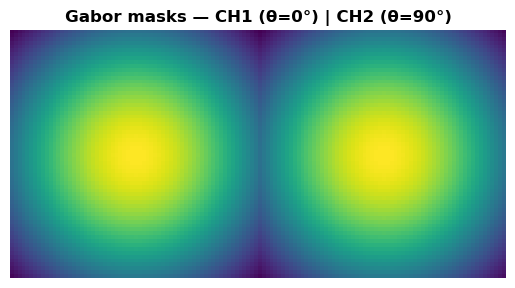

In [ ]:
def myfft2(A):
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(A)))


def gabor_THIS(A, GM1, GM2):
    """
    Gabor encoder — direct replacement for Baurzhan's vort_THIS.

    Takes a batch of images and applies:
    1. Phase encode: exp(i * image * pi/2)  — same as Baurzhan
    2. Multiply by Lens
    3. FFT (myfft2)
    4. Multiply by Gabor mask in Fourier plane — replaces vortex mask
    5. Take magnitude
    6. Normalise to [-1, 1]
    7. Concatenate dual channel

    Can be applied to both:
    - Gaussian beam speckles (Method 1 training)
    - Real chest X-ray images (Method 2 training + inference)

    Parameters
    ----------
    A   : (N, H, W) float32 — batch of images in [0,1]
    GM1 : (H, W) float64   — Gabor Fourier mask channel 1
    GM2 : (H, W) float64   — Gabor Fourier mask channel 2

    Returns
    -------
    out : (N, H, W*2) float32 — dual channel Gabor encoded, normalised to [-1,1]
    """
    length = A.shape[0]
    out    = np.zeros((length, A.shape[1], A.shape[2] * 2), dtype=np.float32)

    for i in range(length):
        phase = np.exp(1j * A[i].astype(np.float64) * np.pi / 2)

        A1 = np.abs(myfft2(phase * Lens) * GM1).astype(np.float32)
        A2 = np.abs(myfft2(phase * Lens) * GM2).astype(np.float32)

        A1 = (A1 - np.amin(A1)) / (np.amax(A1 - np.amin(A1)) + 1e-8) * 2 - 1
        A2 = (A2 - np.amin(A2)) / (np.amax(A2 - np.amin(A2)) + 1e-8) * 2 - 1

        out[i] = np.hstack((A1, A2))

    return out


def make_gabor_mask(DIM=64, omega_0=0.07, theta=0, sigma_f=0.5):
    """
    Gabor mask in the Fourier plane.
    Gaussian blob centred at (omega_0, theta) — bandpass filter.

    Parameters
    ----------
    DIM     : int   — image dimension
    omega_0 : float — centre frequency in cycles/pixel
    theta   : float — orientation in radians
    sigma_f : float — bandwidth

    Returns
    -------
    mask : (DIM, DIM) float64 in [0,1]
    """
    freqs = np.fft.fftshift(np.fft.fftfreq(DIM))
    U, V  = np.meshgrid(freqs, freqs)

    u0 = omega_0 * np.cos(theta)
    v0 = omega_0 * np.sin(theta)

    mask_pos = np.exp(-((U - u0)**2 + (V - v0)**2) / (2 * sigma_f**2))
    mask_neg = np.exp(-((U + u0)**2 + (V + v0)**2) / (2 * sigma_f**2))

    mask = mask_pos + mask_neg
    mask = mask / mask.max()

    return mask.astype(np.float64)


# ── Coordinates + Lens — same as Baurzhan ─────────────────────────────────────
DIM     = 256
xmax    = 10
dx      = 2 * xmax / DIM

x       = np.linspace(-xmax, xmax - dx, DIM)
X, Y    = np.meshgrid(x, x)
R2      = X**2 + Y**2
T       = np.arctan2(Y, X)

flambda = 80
Lens    = np.exp(-1j * R2 / (flambda / 10))

# ── Gabor masks ───────────────────────────────────────────────────────────────
GM1 = make_gabor_mask(DIM, omega_0=0.07, theta=0,       sigma_f=0.5)
GM2 = make_gabor_mask(DIM, omega_0=0.07, theta=np.pi/2, sigma_f=0.5)

plt.imshow(np.hstack((GM1, GM2)), cmap='viridis')
plt.title('Gabor masks — CH1 (θ=0°) | CH2 (θ=90°)', fontweight='bold')
plt.axis('off')
plt.show()


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from skimage.exposure import equalize_adapthist
from skimage.filters import gaussian as sk_gaussian
from tqdm import tqdm
import psutil
from scipy.ndimage import uniform_filter, gaussian_filter

DIM         = 256
NUM_CLASSES = 2

TRAIN_DIR = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/train'
TEST_DIR  = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/test'

# ── Load raw data ─────────────────────────────────────────────────────────────
def load_data(data_dir, dim=DIM):
    ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode='int',
        image_size=(dim, dim),
        batch_size=None,
        shuffle=False
    )
    x = np.array([item[0].numpy() for item in ds])
    y = np.array([item[1].numpy() for item in ds])
    return x, y

print('Loading training data...')
x_train_raw, y_train_int = load_data(TRAIN_DIR)
print('Loading test data...')
x_test_raw,  y_test_int  = load_data(TEST_DIR)

n_train, n_test = len(x_train_raw), len(x_test_raw)
print(f'Train: {n_train} | Test: {n_test}')

# Verify class order — Keras sorts alphabetically
class_names = sorted(os.listdir(TRAIN_DIR))
print(f'Class order: {class_names}')  # [NORMAL, PNEUMONIA] -> 0, 1

# ── Grayscale + normalise ─────────────────────────────────────────────────────
def to_gray_norm(images_rgb, N):
    out = np.empty((N, DIM, DIM), dtype=np.float32)
    for i in tqdm(range(N), desc='Grayscale+Norm'):
        gray   = cv2.cvtColor(images_rgb[i].astype(np.uint8),
                               cv2.COLOR_RGB2GRAY)
        out[i] = gray / 255.0
    return out

x_train_gray = to_gray_norm(x_train_raw, n_train)
x_test_gray  = to_gray_norm(x_test_raw,  n_test)
del x_train_raw, x_test_raw

# ── One-hot labels ────────────────────────────────────────────────────────────
y_train = to_categorical(y_train_int, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_int,  num_classes=NUM_CLASSES)

# ── Preprocessing — CLAHE + central crop + smoothing (no segmentation) ────────
def preprocess_xray(img):
    """
    Input : (64, 64) float32 in [0,1] — grayscale, normalised
    Output: (64, 64) float32 in [0,1]
    Steps : CLAHE → fixed central crop → resize → Gaussian smooth → renorm
    """
    # 1. CLAHE
    img = equalize_adapthist(img, clip_limit=0.03).astype(np.float32)
    # 2. Fixed central crop — removes chest wall borders
    h, w  = img.shape
    pad_h = int(h * 0.10)
    pad_w = int(w * 0.08)
    img   = img[pad_h:h-pad_h, pad_w:w-pad_w]
    # 3. Resize back to 64x64
    img = cv2.resize(img, (DIM, DIM), interpolation=cv2.INTER_AREA)
    # 4. Gaussian smoothing
    img = sk_gaussian(img, sigma=0.5).astype(np.float32)
    # 5. Re-normalise
    if img.max() > 1e-8:
        img = img / img.max()
    return img

print('Preprocessing training images...')
x_train_normal = np.zeros((n_train, DIM, DIM), dtype=np.float32)
for i in tqdm(range(n_train), desc='Train'):
    x_train_normal[i] = preprocess_xray(x_train_gray[i])

print('Preprocessing test images...')
x_test_normal = np.zeros((n_test, DIM, DIM), dtype=np.float32)
for i in tqdm(range(n_test), desc='Test'):
    x_test_normal[i] = preprocess_xray(x_test_gray[i])

del x_train_gray, x_test_gray


def apply_smooth_region_filter(image, window=20):
    """
    Suppresses high-contrast edge regions (ribs) and preserves
    smooth regions (consolidation opacity).

    Parameters
    ----------
    image  : (H, W) float32 in [0,1]
    window : int — neighbourhood size (5-7 at 64×64, 9-11 at 128×128)

    Returns
    -------
    filtered : (H, W) float32 in [0,1] — edge-suppressed image
    """
    mean_sq   = uniform_filter(image**2, size=window)
    sq_mean   = uniform_filter(image,    size=window)**2
    local_std = np.sqrt(np.clip(mean_sq - sq_mean, 0, None)).astype(np.float32)

    # Smooth mask — inverse of normalised local std
    s_rng = local_std.max() - local_std.min()
    local_std_norm  = (local_std - local_std.min()) / (s_rng + 1e-8)
    smooth_mask     = gaussian_filter(1.0 - local_std_norm, sigma=1.0)

    # Apply and renormalise
    filtered = image * smooth_mask
    f_rng    = filtered.max() - filtered.min()
    filtered = (filtered - filtered.min()) / (f_rng + 1e-8)

    return filtered.astype(np.float32)


x_train = np.zeros((n_train, DIM, DIM), dtype=np.float32)
x_test = np.zeros((n_test, DIM, DIM), dtype=np.float32)

for i, img in enumerate(x_train_normal):
    x_train[i] = apply_smooth_region_filter(img)

for i, img in enumerate(x_test_normal):
    x_test[i] = apply_smooth_region_filter(img)

del x_train_normal, x_test_normal


# ── Verify class split ────────────────────────────────────────────────────────
N_NORMAL    = int(np.sum(y_train_int == 0))
N_PNEUMONIA = int(np.sum(y_train_int == 1))
print(f'\nNormal    : {N_NORMAL}  (idx 0 to {N_NORMAL-1})')
print(f'Pneumonia : {N_PNEUMONIA}  (idx {N_NORMAL} to {n_train-1})')
print(f'x_train   : {x_train.shape}')
print(f'x_test    : {x_test.shape}')

ram = psutil.virtual_memory()
print(f'RAM available: {ram.available/1e9:.1f} GB')


Loading training data...
Found 5216 files belonging to 2 classes.


I0000 00:00:1777578037.685385   19960 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7535 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-04-30 12:40:45.774719: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Loading test data...
Found 624 files belonging to 2 classes.


2026-04-30 12:40:52.279042: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-30 12:40:53.586393: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Train: 5216 | Test: 624
Class order: ['NORMAL', 'PNEUMONIA']


...

Preprocessing training images...


Train: 100%|██████████| 5216/5216 [00:13<00:00, 400.47it/s]


Preprocessing test images...


Test: 100%|██████████| 624/624 [00:01<00:00, 407.92it/s]



Normal    : 1341  (idx 0 to 1340)
Pneumonia : 3875  (idx 1341 to 5215)
x_train   : (5216, 64, 64)
x_test    : (624, 64, 64)
RAM available: 11.9 GB


In [5]:
import numpy as np
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import skew
from tqdm import tqdm

def compute_top10_features(image):
    """
    Computes the top 10 most discriminative statistics
    for chest X-ray pneumonia detection.

    Parameters
    ----------
    image : (H, W) float32 in [0,1] — preprocessed chest X-ray

    Returns
    -------
    features     : (10,) float32
    feature_names: list of 10 strings
    """
    H, W  = image.shape
    lower = image[H//2:, :]
    upper = image[:H//2, :]
    left  = image[:, :W//2]
    right = image[:, W//2:]

    features = []
    names    = []

    # 1 — Lower lobe mean
    features.append(float(lower.mean()))
    names.append('lower_mean')

    # 2 — Low-to-high frequency power ratio
    F       = np.fft.fftshift(np.fft.fft2(image))
    power   = np.abs(F)**2
    freqs   = np.fft.fftshift(np.fft.fftfreq(H))
    U, V    = np.meshgrid(np.fft.fftshift(np.fft.fftfreq(W)), freqs)
    R       = np.sqrt(U**2 + V**2)
    low_mask  = R < 0.07
    high_mask = R >= 0.15
    lhr     = power[low_mask].mean() / (power[high_mask].mean() + 1e-8)
    features.append(float(lhr))
    names.append('low_high_ratio')

    # 3 — GLCM Homogeneity at distance 5
    img_uint8 = (image * 255).astype(np.uint8)
    glcm_d5   = graycomatrix(img_uint8, distances=[5],
                              angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                              levels=256, symmetric=True, normed=True)
    homogeneity_d5 = float(graycoprops(glcm_d5, 'homogeneity').mean())
    features.append(homogeneity_d5)
    names.append('glcm_homogeneity_d5')

    # 4 — Long Run Emphasis (horizontal direction)
    img_q   = (image * 31).astype(np.int32).clip(0, 31)
    runs    = {}
    for row in img_q:
        val = row[0]; length = 1
        for pixel in row[1:]:
            if pixel == val:
                length += 1
            else:
                runs[(val, length)] = runs.get((val, length), 0) + 1
                val = pixel; length = 1
        runs[(val, length)] = runs.get((val, length), 0) + 1

    lengths = np.array([k[1] for k in runs.keys()], dtype=np.float32)
    counts  = np.array(list(runs.values()),          dtype=np.float32)
    total   = counts.sum()
    lre     = float(np.sum(counts * lengths**2) / (total + 1e-8))
    features.append(lre)
    names.append('long_run_emphasis')

    # 5 — Left-right asymmetry
    lr_asym = float(np.abs(left.mean() - right.mean()))
    features.append(lr_asym)
    names.append('lr_asymmetry')

    # 6 — Global mean intensity
    features.append(float(image.mean()))
    names.append('global_mean')

    # 7 — GLCM Energy
    glcm_d1 = graycomatrix(img_uint8, distances=[1],
                             angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                             levels=256, symmetric=True, normed=True)
    energy  = float(graycoprops(glcm_d1, 'energy').mean())
    features.append(energy)
    names.append('glcm_energy')

    # 8 — Lower lobe standard deviation
    features.append(float(lower.std()))
    names.append('lower_std')

    # 9 — DC power
    dc_power = float(np.abs(F[H//2, W//2])**2)   # DC is at centre after fftshift
    dc_norm  = dc_power / (image.size**2 + 1e-8)  # normalise by image size
    features.append(dc_norm)
    names.append('dc_power')

    # 10 — Skewness
    features.append(float(skew(image.flatten())))
    names.append('skewness')

    return np.array(features, dtype=np.float32), names


# ── Extract for all training images ──────────────────────────────────────────
sample_feat, feature_names = compute_top10_features(x_train[0])
print(f'Features per image : {len(feature_names)}')
print(f'Feature names      : {feature_names}')

X_stats = np.zeros((len(x_train), 10), dtype=np.float32)

for i in tqdm(range(len(x_train)), desc='Extracting features'):
    X_stats[i], _ = compute_top10_features(x_train[i])

print(f'\nFeature matrix shape: {X_stats.shape}')

# ── Quick Fisher ratio check ──────────────────────────────────────────────────
y_ints = np.argmax(y_train, axis=1)

print(f'\n{"Feature":>22}  {"Fisher":>8}  {"Normal":>8}  {"Pneumonia":>10}  {"Direction"}')
print('-' * 70)

for i, name in enumerate(feature_names):
    vals_n = X_stats[y_ints == 0, i]
    vals_p = X_stats[y_ints == 1, i]
    fisher = (vals_p.mean() - vals_n.mean())**2 / \
             (vals_p.std()**2 + vals_n.std()**2 + 1e-8)
    direction = '↑ pneumonia' if vals_p.mean() > vals_n.mean() else '↓ pneumonia'
    print(f'{name:>22}  {fisher:8.4f}  '
          f'{vals_n.mean():8.4f}  {vals_p.mean():10.4f}  {direction}')

Features per image : 10
Feature names      : ['lower_mean', 'low_high_ratio', 'glcm_homogeneity_d5', 'long_run_emphasis', 'lr_asymmetry', 'global_mean', 'glcm_energy', 'lower_std', 'dc_power', 'skewness']


Extracting features: 100%|██████████| 5216/5216 [00:56<00:00, 92.37it/s]


Feature matrix shape: (5216, 10)

               Feature    Fisher    Normal   Pneumonia  Direction
----------------------------------------------------------------------
            lower_mean    0.5053    0.3187      0.3790  ↑ pneumonia
        low_high_ratio    1.0902  2781.4604   5175.3599  ↑ pneumonia
   glcm_homogeneity_d5    0.1244    0.0363      0.0398  ↑ pneumonia
     long_run_emphasis    0.0555    2.6633      2.8251  ↑ pneumonia
          lr_asymmetry    0.2902    0.0429      0.0832  ↑ pneumonia
           global_mean    0.2038    0.3158      0.3496  ↑ pneumonia
           glcm_energy    0.0170    0.0187      0.0202  ↑ pneumonia
             lower_std    1.0830    0.2006      0.2404  ↑ pneumonia
              dc_power    0.2018    0.1019      0.1257  ↑ pneumonia
              skewness    0.0145    0.7189      0.6571  ↓ pneumonia


After standardisation:
Mean per feature : [ 0. -0. -0. -0.  0.  0. -0. -0.  0.  0.]
Std  per feature : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Variance explained per PC:
  PC 1:  42.59%   cumulative:  42.59%
  PC 2:  25.08%   cumulative:  67.67%
  PC 3:  10.56%   cumulative:  78.23%
  PC 4:   7.87%   cumulative:  86.10%
  PC 5:   5.46%   cumulative:  91.55%
  PC 6:   4.52%   cumulative:  96.07%
  PC 7:   2.13%   cumulative:  98.20%
  PC 8:   0.97%   cumulative:  99.17%
  PC 9:   0.77%   cumulative:  99.95%
  PC10:   0.05%   cumulative: 100.00%

   PC    Fisher    Var %   Normal mean  Pneumonia mean
-------------------------------------------------------
  PC 1    0.4250    42.59%       -1.2323          0.4265
  PC 2    0.3984    25.08%       -0.9200          0.3184
  PC 3    0.2295    10.56%        0.4593         -0.1590
  PC 4    0.0011     7.87%        0.0276         -0.0096
  PC 5    0.1323     5.46%        0.2559         -0.0886
  PC 6    0.0032     4.52%        0.0369         -0.0128
  P

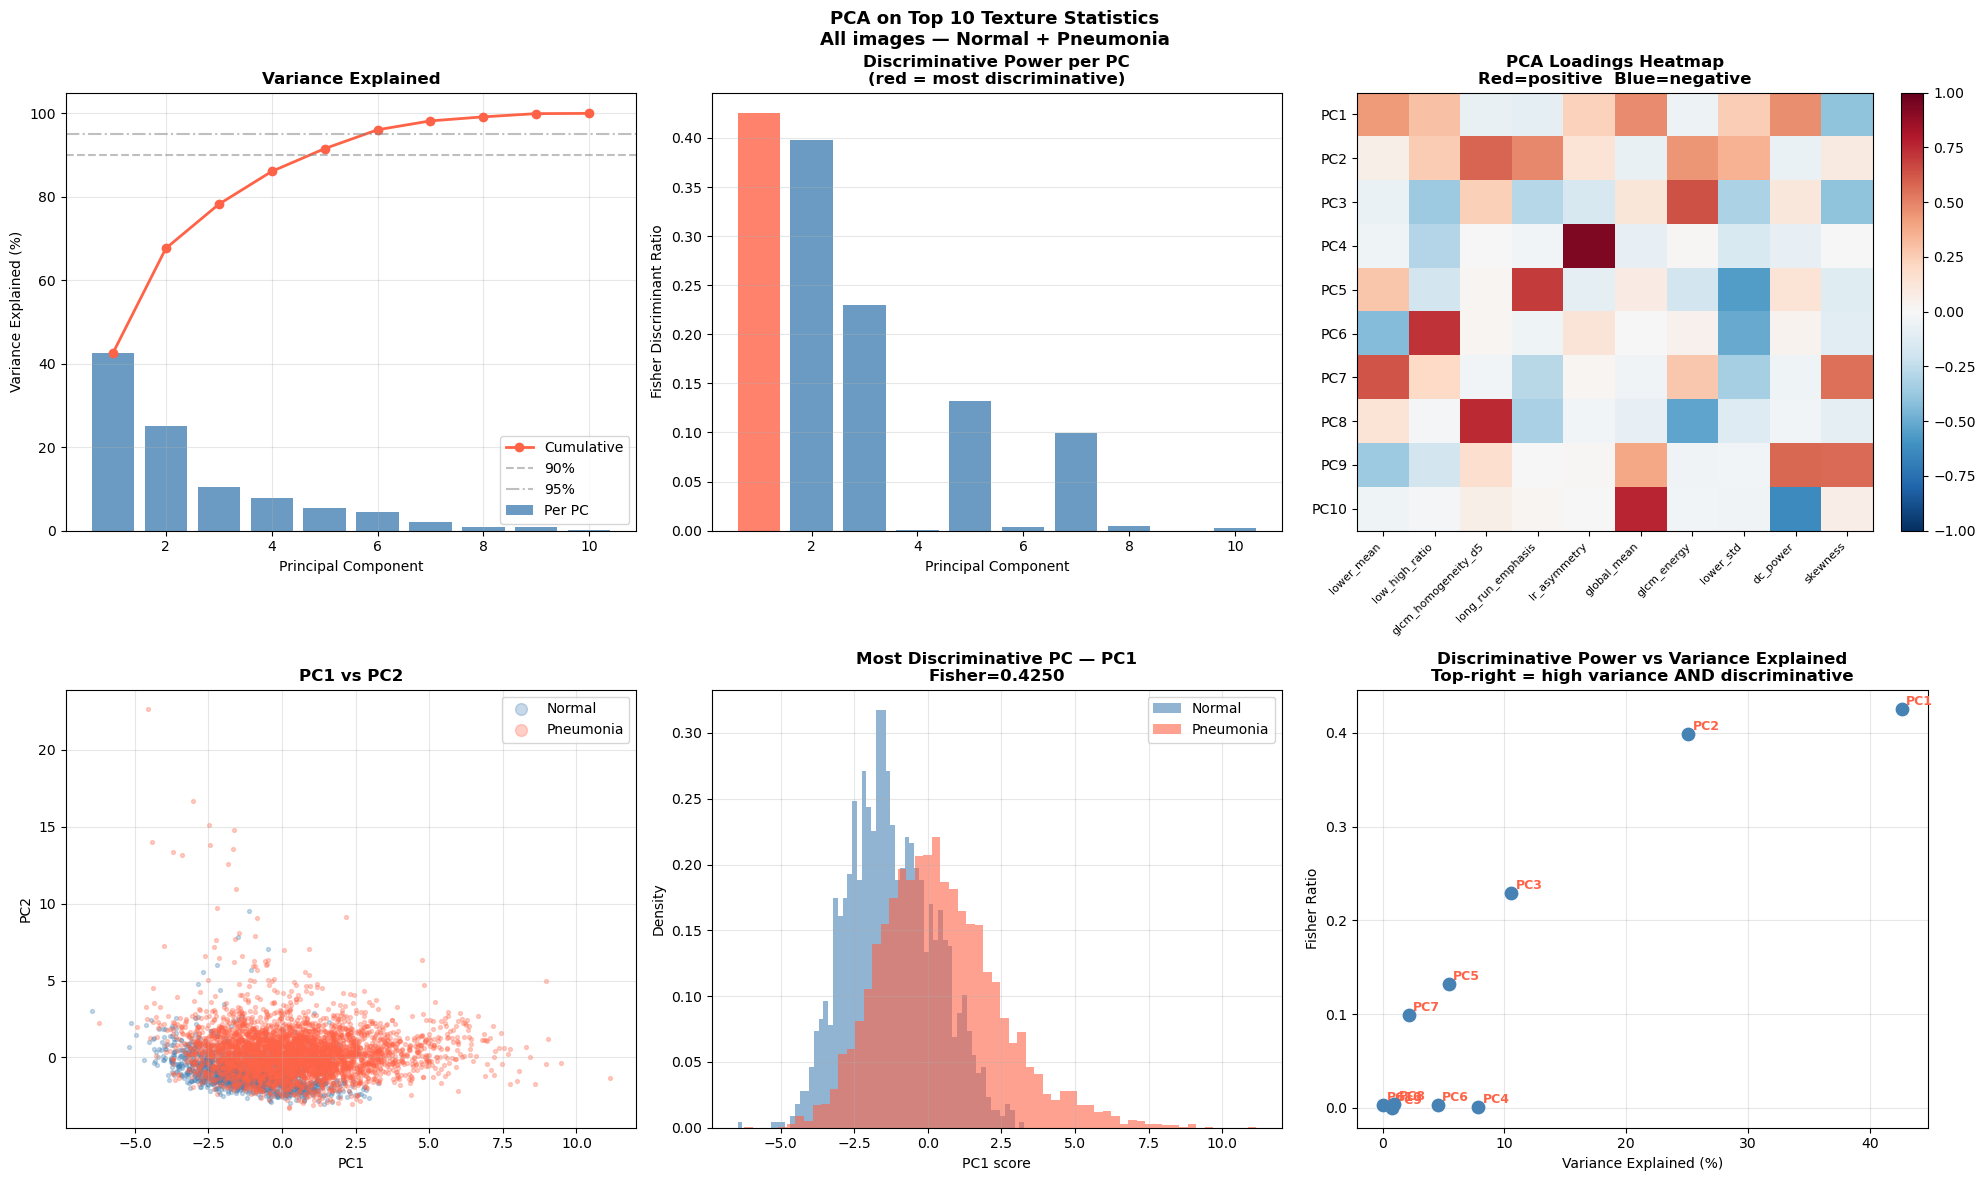

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

y_ints = np.argmax(y_train, axis=1)

# ── Step 1: Standardise — critical since features have very different scales ──
# low_high_ratio is in thousands, lr_asymmetry is in 0.04-0.08
# Without standardisation PCA is dominated by the largest-scale feature

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_stats)   # (N, 10) — mean=0, std=1 per feature

print('After standardisation:')
print(f'Mean per feature : {X_scaled.mean(axis=0).round(3)}')
print(f'Std  per feature : {X_scaled.std(axis=0).round(3)}')

# ── Step 2: Fit PCA on all images ─────────────────────────────────────────────
# n_components = 10 — we have 10 features so max 10 PCs
pca      = PCA(n_components=10, random_state=42)
X_pca    = pca.fit_transform(X_scaled)   # (N, 10)

print(f'\nVariance explained per PC:')
for i, var in enumerate(pca.explained_variance_ratio_):
    cumvar = pca.explained_variance_ratio_[:i+1].sum() * 100
    print(f'  PC{i+1:2d}: {var*100:6.2f}%   cumulative: {cumvar:6.2f}%')

# ── Step 3: Fisher ratio per PC ───────────────────────────────────────────────
proj_normal    = X_pca[y_ints == 0]   # (N_n, 10)
proj_pneumonia = X_pca[y_ints == 1]   # (N_p, 10)

fisher = (proj_pneumonia.mean(axis=0) - proj_normal.mean(axis=0))**2 / \
         (proj_pneumonia.std(axis=0)**2 + proj_normal.std(axis=0)**2 + 1e-8)

print(f'\n{"PC":>5}  {"Fisher":>8}  {"Var %":>7}  {"Normal mean":>12}  {"Pneumonia mean":>14}')
print('-' * 55)
for i in range(10):
    print(f'  PC{i+1:2d}  {fisher[i]:8.4f}  '
          f'{pca.explained_variance_ratio_[i]*100:7.2f}%  '
          f'{proj_normal[:,i].mean():12.4f}  '
          f'{proj_pneumonia[:,i].mean():14.4f}')

# ── Step 4: Loadings — what does each PC represent ───────────────────────────
print(f'\nPC loadings — which statistics drive each PC:')
print(f'{"":>22}', end='')
for i in range(10):
    print(f'  PC{i+1:2d}', end='')
print()
print('-' * 102)
for j, name in enumerate(feature_names):
    print(f'{name:>22}', end='')
    for i in range(10):
        print(f'  {pca.components_[i,j]:+5.2f}', end='')
    print()

# ── Step 5: Plot everything ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Variance explained
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
axes[0,0].bar(range(1,11), pca.explained_variance_ratio_*100,
              color='steelblue', alpha=0.8, label='Per PC')
axes[0,0].plot(range(1,11), cumvar, color='tomato',
               marker='o', linewidth=2, label='Cumulative')
axes[0,0].axhline(90, color='grey', linestyle='--', alpha=0.5, label='90%')
axes[0,0].axhline(95, color='grey', linestyle='-.',  alpha=0.5, label='95%')
axes[0,0].set_xlabel('Principal Component')
axes[0,0].set_ylabel('Variance Explained (%)')
axes[0,0].set_title('Variance Explained', fontweight='bold')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Fisher ratio per PC
axes[0,1].bar(range(1,11), fisher,
              color=['tomato' if f == fisher.max() else 'steelblue'
                     for f in fisher], alpha=0.8)
axes[0,1].set_xlabel('Principal Component')
axes[0,1].set_ylabel('Fisher Discriminant Ratio')
axes[0,1].set_title('Discriminative Power per PC\n(red = most discriminative)',
                     fontweight='bold')
axes[0,1].grid(alpha=0.3, axis='y')

# Loadings heatmap
im = axes[0,2].imshow(pca.components_, cmap='RdBu_r', aspect='auto',
                       vmin=-1, vmax=1)
axes[0,2].set_xticks(range(10))
axes[0,2].set_xticklabels(feature_names, rotation=45, ha='right', fontsize=8)
axes[0,2].set_yticks(range(10))
axes[0,2].set_yticklabels([f'PC{i+1}' for i in range(10)])
axes[0,2].set_title('PCA Loadings Heatmap\nRed=positive  Blue=negative',
                     fontweight='bold')
plt.colorbar(im, ax=axes[0,2], fraction=0.046)

# PC1 vs PC2 scatter
axes[1,0].scatter(proj_normal[:,0],    proj_normal[:,1],
                  alpha=0.3, s=8, color='steelblue', label='Normal')
axes[1,0].scatter(proj_pneumonia[:,0], proj_pneumonia[:,1],
                  alpha=0.3, s=8, color='tomato',    label='Pneumonia')
axes[1,0].set_xlabel('PC1'); axes[1,0].set_ylabel('PC2')
axes[1,0].set_title('PC1 vs PC2', fontweight='bold')
axes[1,0].legend(markerscale=3); axes[1,0].grid(alpha=0.3)

# Most discriminative PC score distribution
best_pc = int(np.argmax(fisher))
axes[1,1].hist(proj_normal[:,best_pc],    bins=60, color='steelblue',
               alpha=0.6, density=True, label='Normal')
axes[1,1].hist(proj_pneumonia[:,best_pc], bins=60, color='tomato',
               alpha=0.6, density=True, label='Pneumonia')
axes[1,1].set_xlabel(f'PC{best_pc+1} score')
axes[1,1].set_ylabel('Density')
axes[1,1].set_title(f'Most Discriminative PC — PC{best_pc+1}\n'
                     f'Fisher={fisher[best_pc]:.4f}',
                     fontweight='bold')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

# Fisher ratio vs variance explained scatter
axes[1,2].scatter(pca.explained_variance_ratio_*100, fisher,
                  color='steelblue', s=80, zorder=5)
for i in range(10):
    axes[1,2].annotate(f'PC{i+1}',
                        (pca.explained_variance_ratio_[i]*100, fisher[i]),
                        fontsize=9, color='tomato', fontweight='bold',
                        xytext=(3, 3), textcoords='offset points')
axes[1,2].set_xlabel('Variance Explained (%)')
axes[1,2].set_ylabel('Fisher Ratio')
axes[1,2].set_title('Discriminative Power vs Variance Explained\n'
                     'Top-right = high variance AND discriminative',
                     fontweight='bold')
axes[1,2].grid(alpha=0.3)

plt.suptitle('PCA on Top 10 Texture Statistics\nAll images — Normal + Pneumonia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_statistics_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

Running t-SNE...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 5216 samples in 0.003s...
[t-SNE] Computed neighbors for 5216 samples in 0.342s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5216
[t-SNE] Computed conditional probabilities for sample 2000 / 5216
[t-SNE] Computed conditional probabilities for sample 3000 / 5216
[t-SNE] Computed conditional probabilities for sample 4000 / 5216
[t-SNE] Computed conditional probabilities for sample 5000 / 5216
[t-SNE] Computed conditional probabilities for sample 5216 / 5216
[t-SNE] Mean sigma: 0.550752
[t-SNE] KL divergence after 250 iterations with early exaggeration: 79.233727
[t-SNE] KL divergence after 1000 iterations: 1.730386
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 5216 samples in 0.003s...
[t-SNE] Computed neighbors for 5216 samples in 0.267s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5216
[t-SNE] Computed conditional probabilities for sample 2000 / 5216
[t-SNE] Co

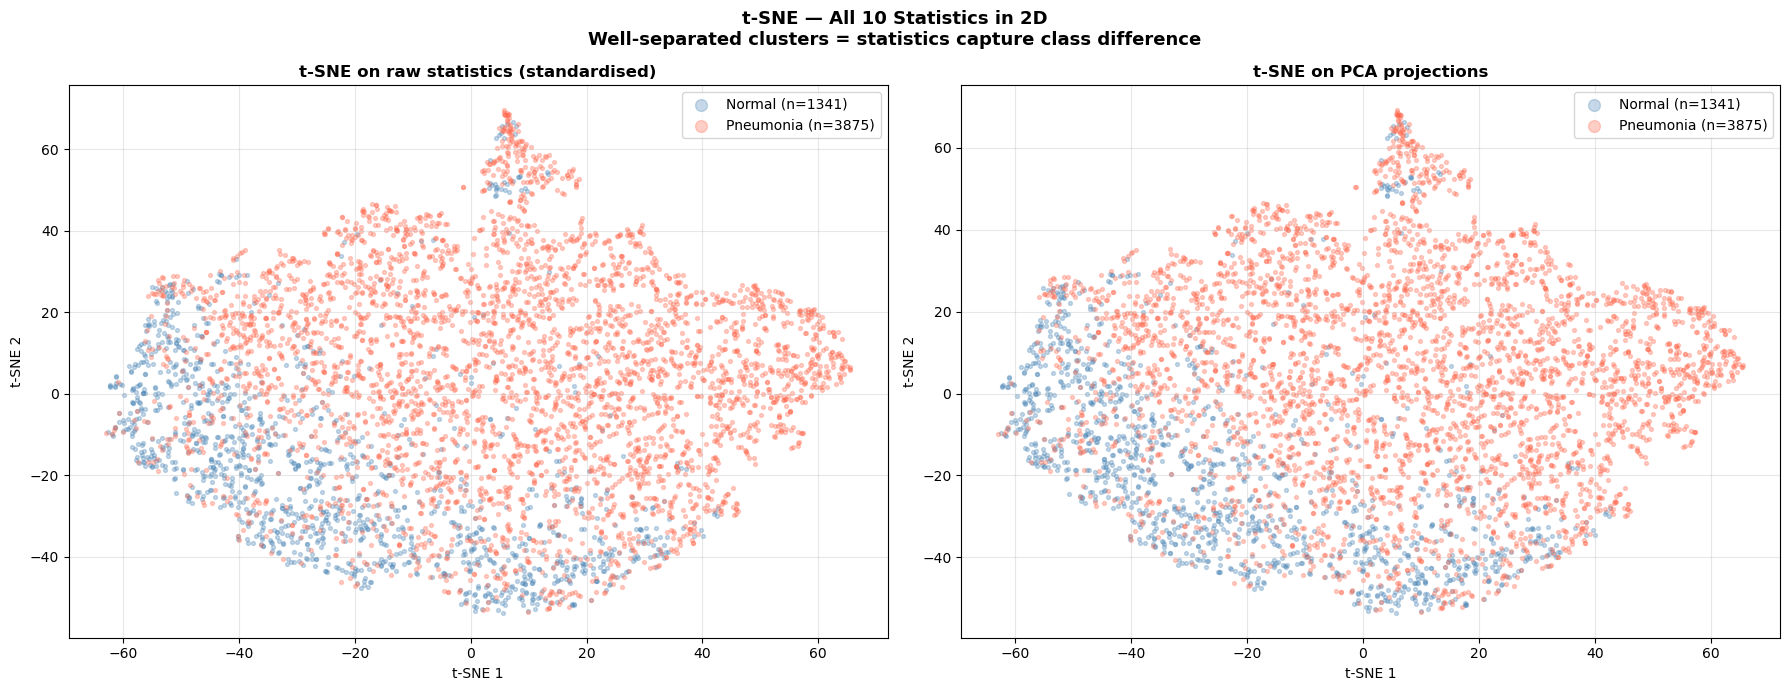

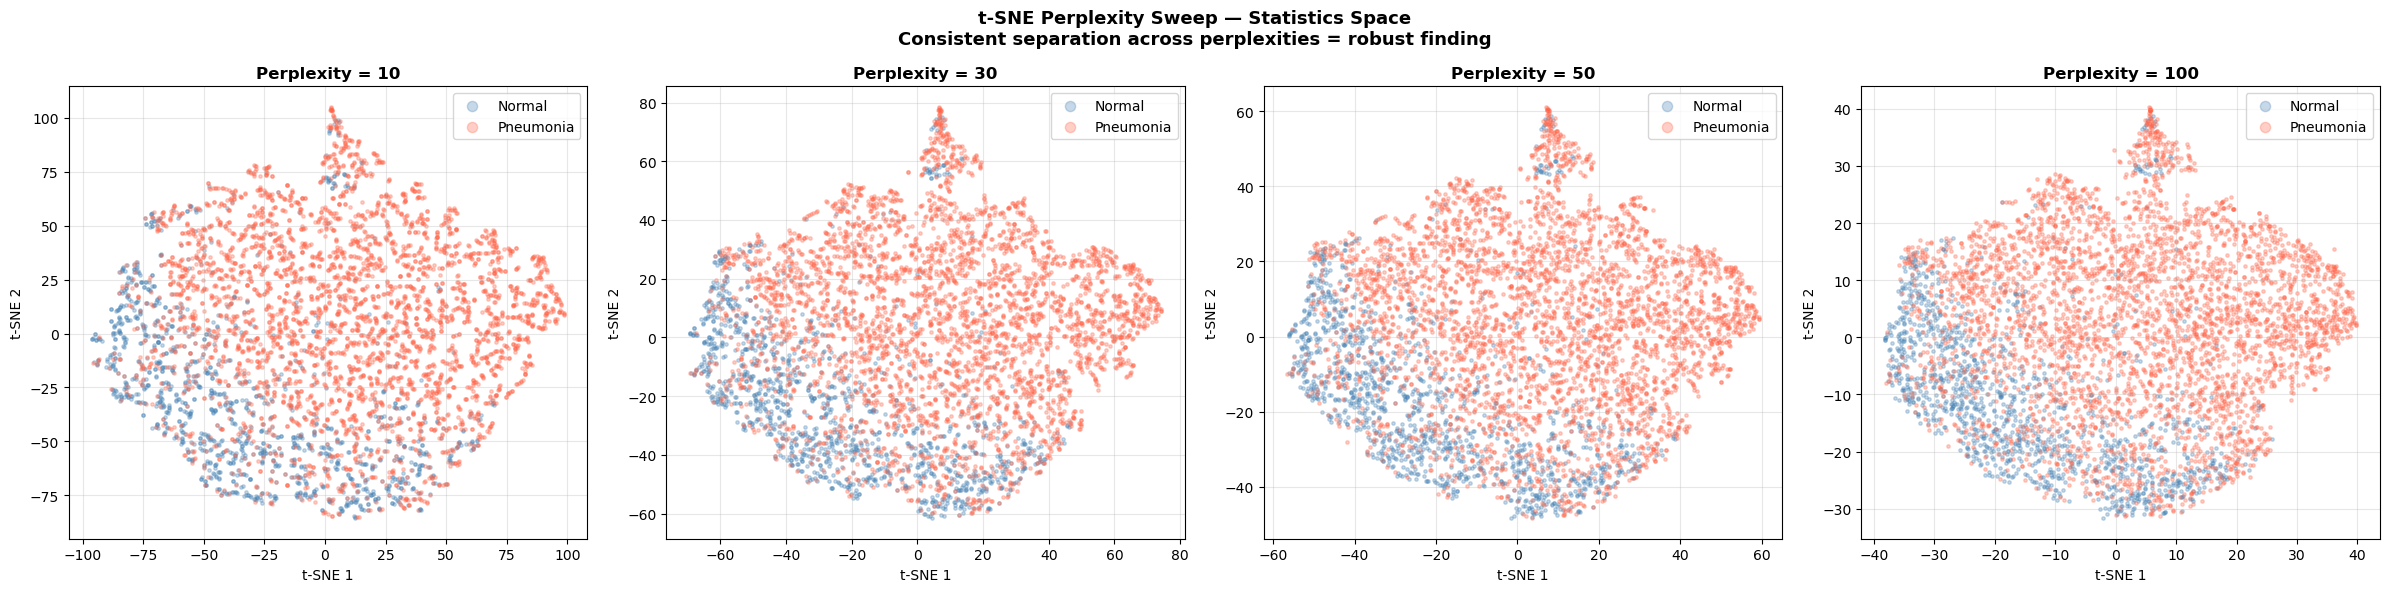

In [17]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# ── Run t-SNE on the standardised statistics ──────────────────────────────────
# Can run on either the raw standardised features or the PCA projections
# Running on PCA projections first is recommended — denoises the data

print('Running t-SNE...')

tsne = TSNE(
    n_components=2,
    perplexity=40,       # controls local vs global structure
                         # try 20, 40, 80 — larger = more global structure
    learning_rate='auto',
    max_iter=1000,
    random_state=42,
    verbose=1
)

# Option A — t-SNE on standardised statistics directly
X_tsne_stats = tsne.fit_transform(X_scaled)   # (N, 2)

# Option B — t-SNE on PCA projections (faster, denoised)
tsne2        = TSNE(n_components=2, perplexity=40,
                    learning_rate='auto', max_iter=1000,
                    random_state=42, verbose=1)
X_tsne_pca   = tsne2.fit_transform(X_pca)     # (N, 2)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, X_tsne, title in [
    (axes[0], X_tsne_stats, 't-SNE on raw statistics (standardised)'),
    (axes[1], X_tsne_pca,   't-SNE on PCA projections'),
]:
    ax.scatter(X_tsne[y_ints==0, 0], X_tsne[y_ints==0, 1],
               alpha=0.3, s=8, color='steelblue', label=f'Normal (n={int((y_ints==0).sum())})')
    ax.scatter(X_tsne[y_ints==1, 0], X_tsne[y_ints==1, 1],
               alpha=0.3, s=8, color='tomato',    label=f'Pneumonia (n={int((y_ints==1).sum())})')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(markerscale=3)
    ax.grid(alpha=0.3)

plt.suptitle('t-SNE — All 10 Statistics in 2D\n'
             'Well-separated clusters = statistics capture class difference',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Sweep perplexity — t-SNE is sensitive to this parameter ──────────────────
perplexities = [10, 30, 50, 100]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, perp in zip(axes, perplexities):
    tsne_p = TSNE(n_components=2, perplexity=perp,
                  learning_rate='auto', max_iter=1000,
                  random_state=42)
    X_p    = tsne_p.fit_transform(X_scaled)

    ax.scatter(X_p[y_ints==0, 0], X_p[y_ints==0, 1],
               alpha=0.3, s=6, color='steelblue', label='Normal')
    ax.scatter(X_p[y_ints==1, 0], X_p[y_ints==1, 1],
               alpha=0.3, s=6, color='tomato',    label='Pneumonia')
    ax.set_title(f'Perplexity = {perp}', fontweight='bold')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(markerscale=3)
    ax.grid(alpha=0.3)

plt.suptitle('t-SNE Perplexity Sweep — Statistics Space\n'
             'Consistent separation across perplexities = robust finding',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_perplexity_sweep.png', dpi=300, bbox_inches='tight')
plt.show()

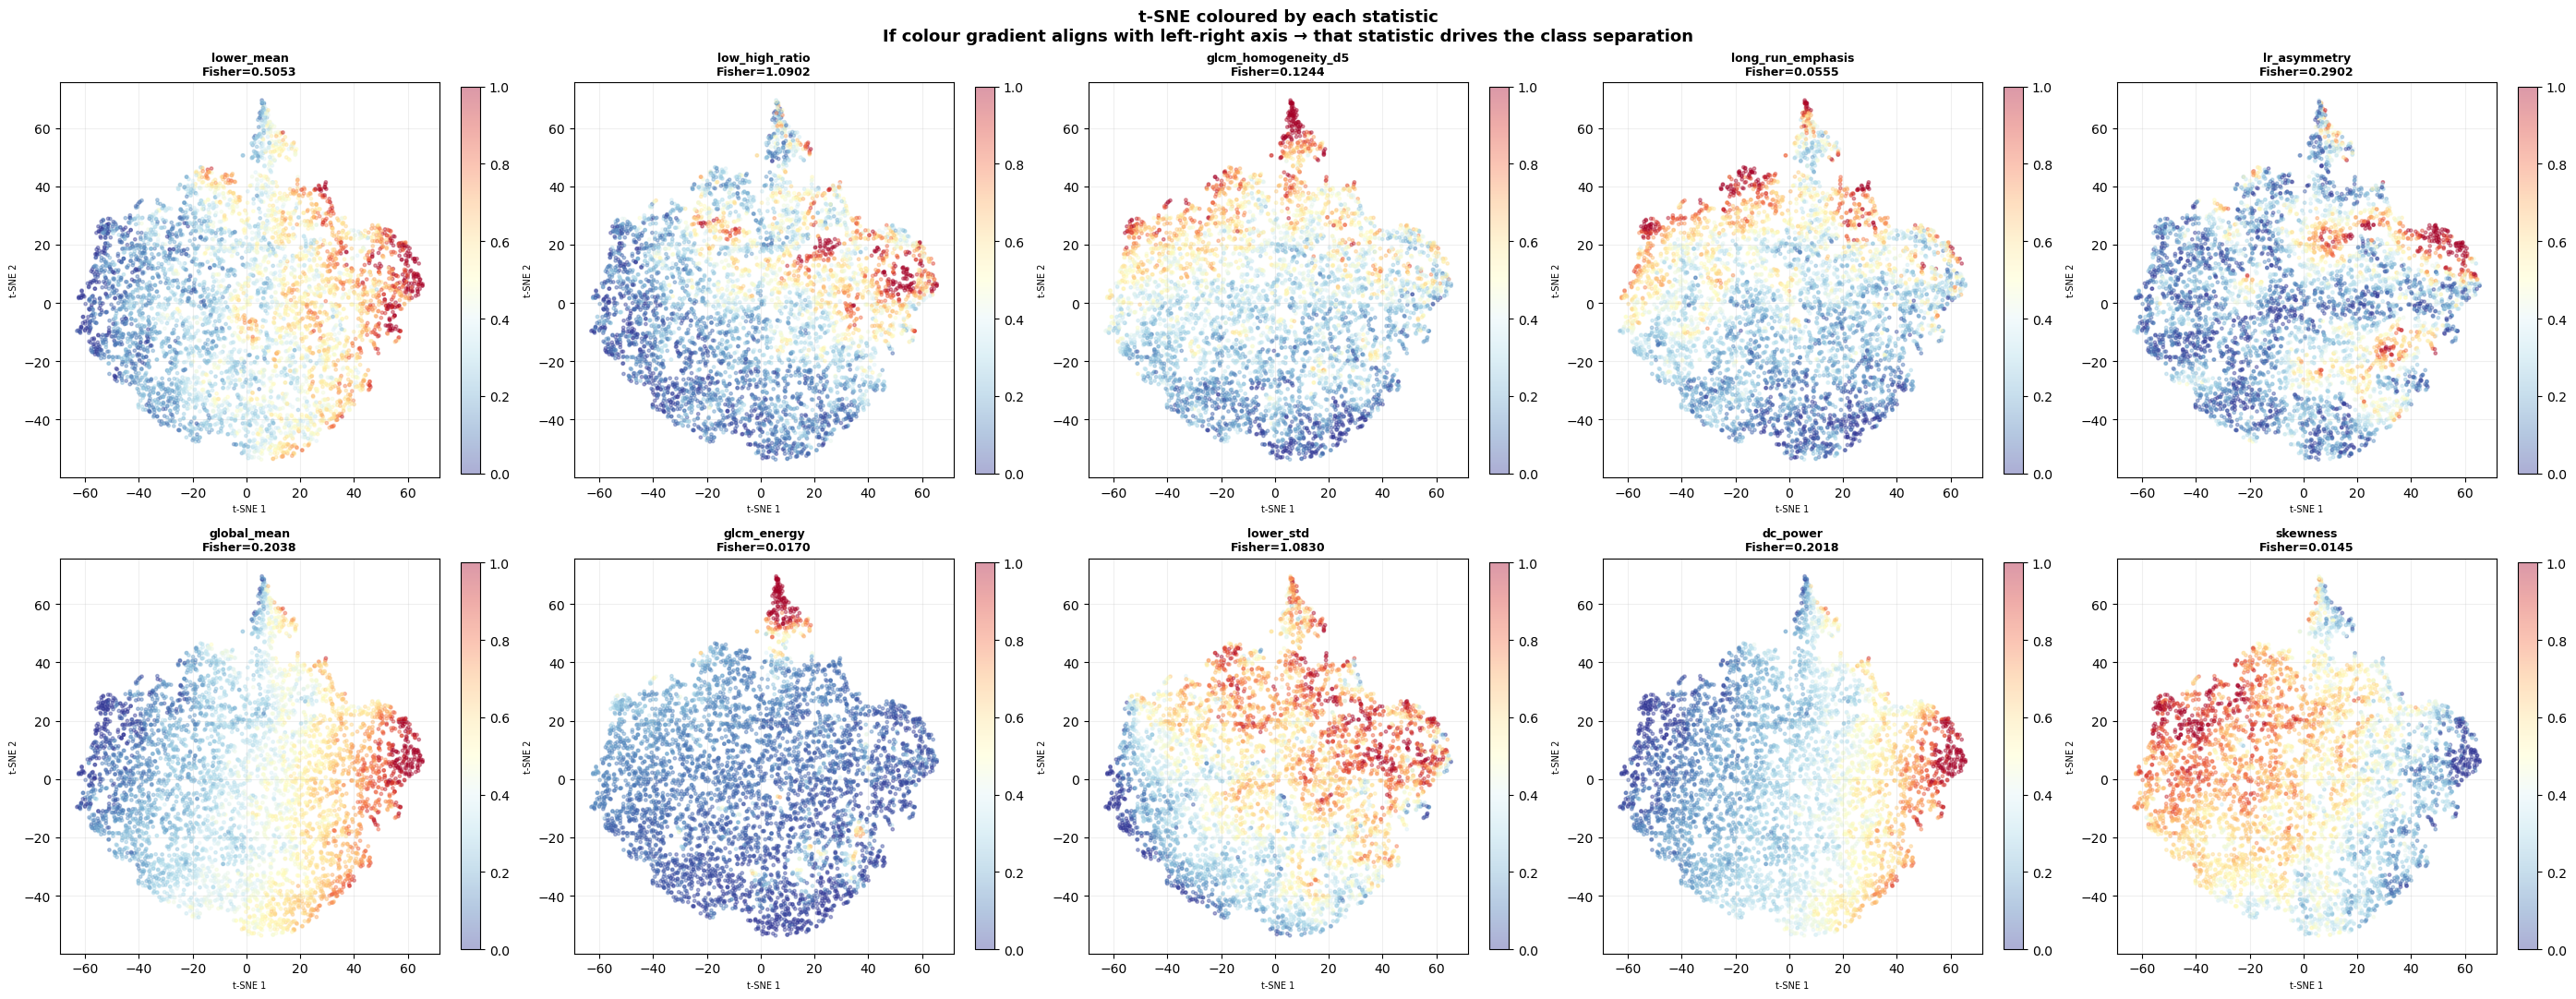

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Use the t-SNE on raw statistics (left plot)
# Colour each point by each of the 10 statistics
# This reveals which statistic drives the left-right separation

fig, axes = plt.subplots(2, 5, figsize=(28, 11))

for idx, (ax, name) in enumerate(zip(axes.flatten(), feature_names)):
    values = X_stats[:, idx]

    # Normalise values to [0,1] for colormap
    v_min  = np.percentile(values, 2)    # robust min
    v_max  = np.percentile(values, 98)   # robust max
    values_norm = np.clip((values - v_min) / (v_max - v_min + 1e-8), 0, 1)

    sc = ax.scatter(X_tsne_stats[:, 0], X_tsne_stats[:, 1],
                    c=values_norm, cmap='RdYlBu_r',
                    alpha=0.4, s=6)
    plt.colorbar(sc, ax=ax, fraction=0.046)

    # Fisher ratio for this feature
    fisher_val = (X_stats[y_ints==1, idx].mean() -
                  X_stats[y_ints==0, idx].mean())**2 / \
                 (X_stats[y_ints==1, idx].std()**2 +
                  X_stats[y_ints==0, idx].std()**2 + 1e-8)

    ax.set_title(f'{name}\nFisher={fisher_val:.4f}',
                  fontweight='bold', fontsize=9)
    ax.set_xlabel('t-SNE 1', fontsize=7)
    ax.set_ylabel('t-SNE 2', fontsize=7)
    ax.grid(alpha=0.2)

plt.suptitle('t-SNE coloured by each statistic\n'
             'If colour gradient aligns with left-right axis → '
             'that statistic drives the class separation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_coloured_by_statistic.png', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
PCA_feature = [0, 1, 4, 5, 7, 8]

X_stats_update = X_stats[:, PCA_feature]
feature_name_update = [feature_names[i] for i in PCA_feature]


print(f'\n{"Feature":>22}  {"Fisher":>8}  {"Normal":>8}  {"Pneumonia":>10}  {"Direction"}')
print('-' * 70)

for i, name in enumerate(feature_name_update):
    vals_n = X_stats_update[y_ints == 0, i]
    vals_p = X_stats_update[y_ints == 1, i]
    fisher = (vals_p.mean() - vals_n.mean())**2 / \
             (vals_p.std()**2 + vals_n.std()**2 + 1e-8)
    direction = '↑ pneumonia' if vals_p.mean() > vals_n.mean() else '↓ pneumonia'
    print(f'{name:>22}  {fisher:8.4f}  '
          f'{vals_n.mean():8.4f}  {vals_p.mean():10.4f}  {direction}')


               Feature    Fisher    Normal   Pneumonia  Direction
----------------------------------------------------------------------
            lower_mean    0.5053    0.3187      0.3790  ↑ pneumonia
        low_high_ratio    1.0902  2781.4604   5175.3599  ↑ pneumonia
          lr_asymmetry    0.2902    0.0429      0.0832  ↑ pneumonia
           global_mean    0.2038    0.3158      0.3496  ↑ pneumonia
             lower_std    1.0830    0.2006      0.2404  ↑ pneumonia
              dc_power    0.2018    0.1019      0.1257  ↑ pneumonia


After standardisation:
Mean per feature : [-0.  0.  0.  0.  0.  0.]
Std  per feature : [1. 1. 1. 1. 1. 1.]

Variance explained per PC:
  PC 1:  60.34%   cumulative:  60.34%
  PC 2:  15.74%   cumulative:  76.09%
  PC 3:  13.09%   cumulative:  89.18%
  PC 4:   7.53%   cumulative:  96.71%
  PC 5:   3.16%   cumulative:  99.87%
  PC 6:   0.13%   cumulative: 100.00%

   PC    Fisher    Var %   Normal mean  Pneumonia mean
-------------------------------------------------------
  PC 1    0.7624    60.34%       -1.4340          0.4963
  PC 2    0.5117    15.74%       -0.6227          0.2155
  PC 3    0.0086    13.09%        0.0766         -0.0265
  PC 4    0.0037     7.53%        0.0394         -0.0137
  PC 5    0.0559     3.16%       -0.0990          0.0342
  PC 6    0.0011     0.13%       -0.0029          0.0010

PC loadings — which statistics drive each PC:
                        PC 1  PC 2  PC 3  PC 4  PC 5  PC 6
-----------------------------------------------------------------------------

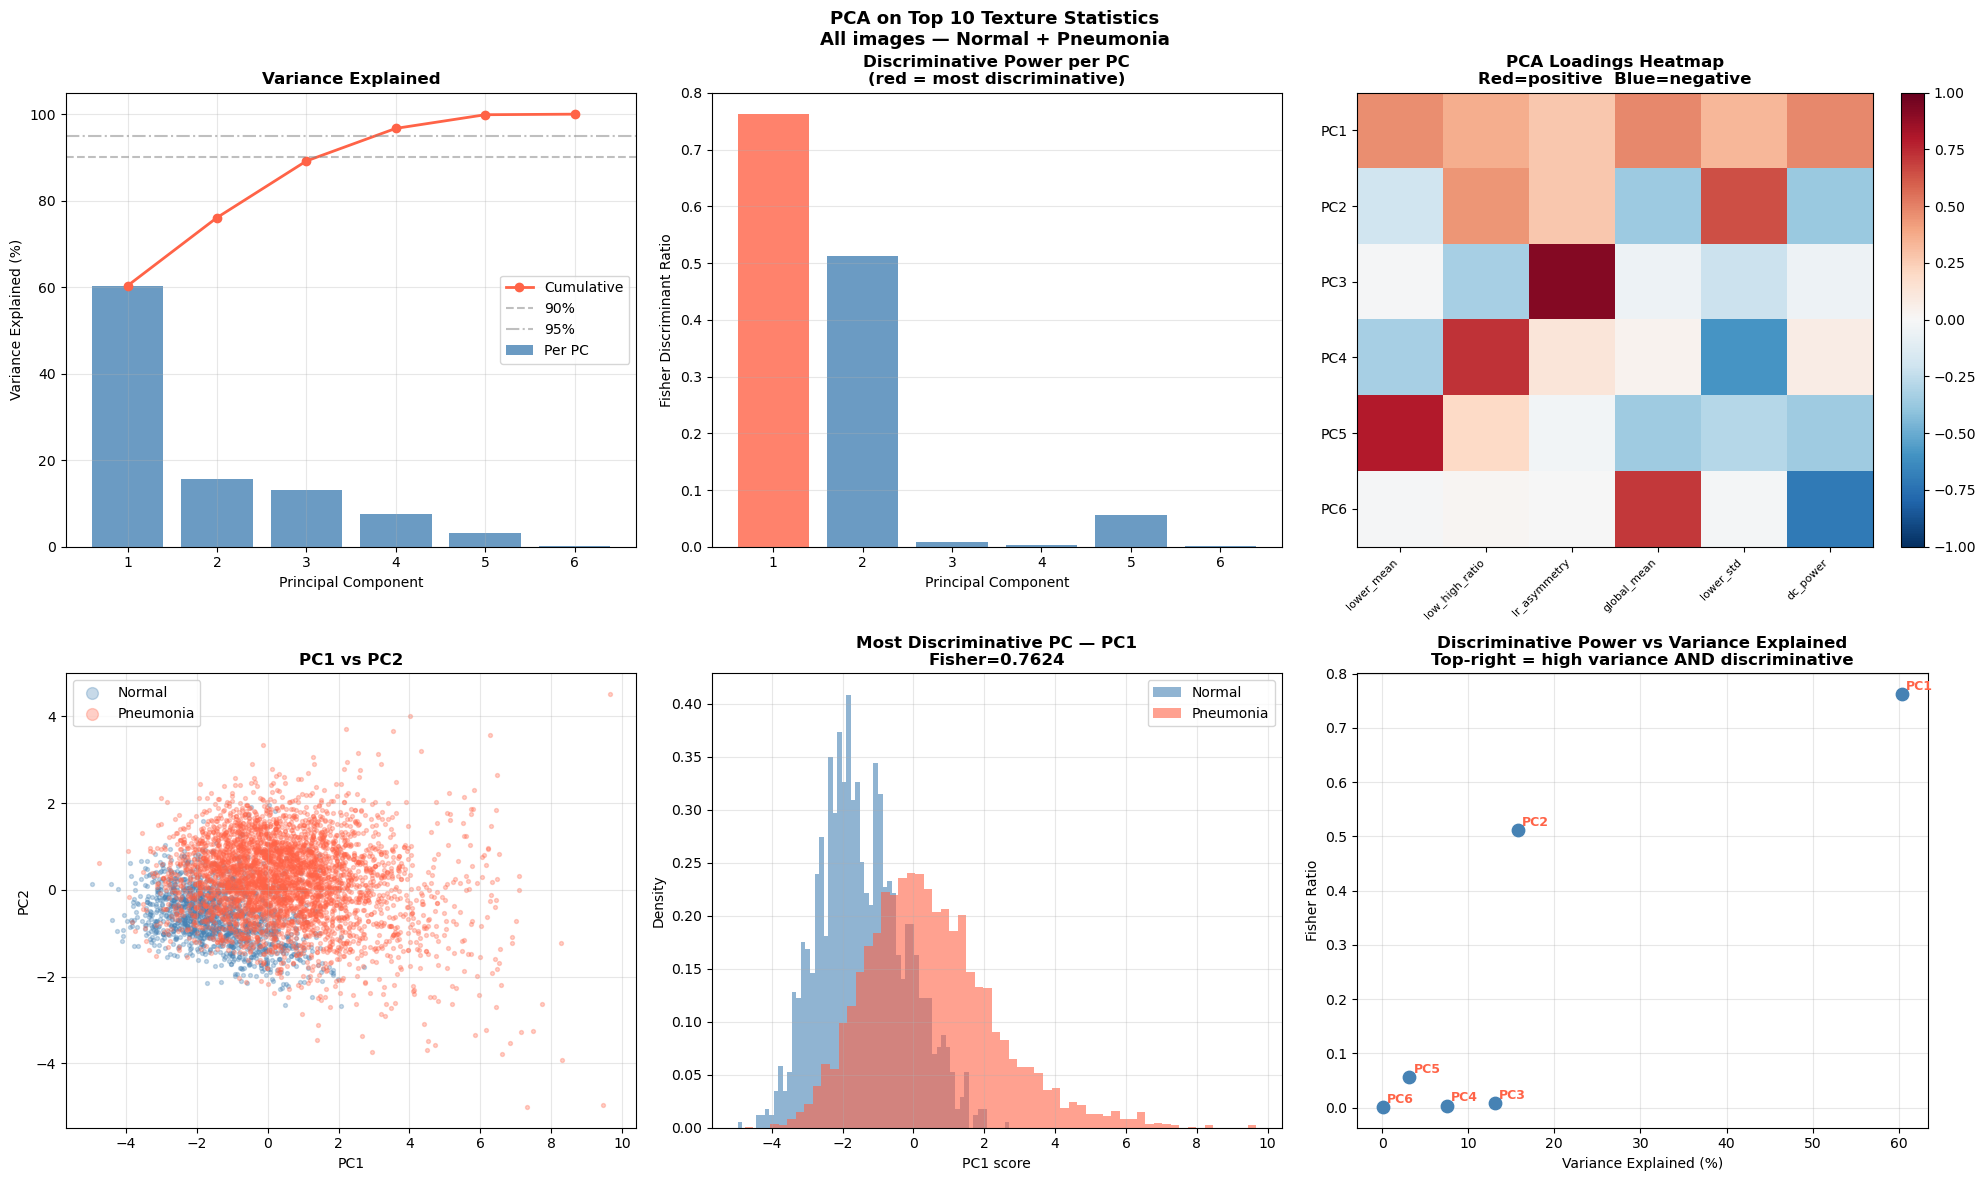

In [45]:
# ── Step 1: Standardise — critical since features have very different scales ──
# low_high_ratio is in thousands, lr_asymmetry is in 0.04-0.08
# Without standardisation PCA is dominated by the largest-scale feature

X_stats = X_stats_update
feature_names = feature_name_update

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_stats)   # (N, 10) — mean=0, std=1 per feature

print('After standardisation:')
print(f'Mean per feature : {X_scaled.mean(axis=0).round(3)}')
print(f'Std  per feature : {X_scaled.std(axis=0).round(3)}')

# ── Step 2: Fit PCA on all images ─────────────────────────────────────────────
# n_components = 10 — we have 10 features so max 10 PCs
pca      = PCA(n_components=6, random_state=42)
X_pca    = pca.fit_transform(X_scaled)   # (N, 10)

print(f'\nVariance explained per PC:')
for i, var in enumerate(pca.explained_variance_ratio_):
    cumvar = pca.explained_variance_ratio_[:i+1].sum() * 100
    print(f'  PC{i+1:2d}: {var*100:6.2f}%   cumulative: {cumvar:6.2f}%')

# ── Step 3: Fisher ratio per PC ───────────────────────────────────────────────
proj_normal    = X_pca[y_ints == 0]   # (N_n, 10)
proj_pneumonia = X_pca[y_ints == 1]   # (N_p, 10)

fisher = (proj_pneumonia.mean(axis=0) - proj_normal.mean(axis=0))**2 / \
         (proj_pneumonia.std(axis=0)**2 + proj_normal.std(axis=0)**2 + 1e-8)

print(f'\n{"PC":>5}  {"Fisher":>8}  {"Var %":>7}  {"Normal mean":>12}  {"Pneumonia mean":>14}')
print('-' * 55)
for i in range(6):
    print(f'  PC{i+1:2d}  {fisher[i]:8.4f}  '
          f'{pca.explained_variance_ratio_[i]*100:7.2f}%  '
          f'{proj_normal[:,i].mean():12.4f}  '
          f'{proj_pneumonia[:,i].mean():14.4f}')

# ── Step 4: Loadings — what does each PC represent ───────────────────────────
print(f'\nPC loadings — which statistics drive each PC:')
print(f'{"":>22}', end='')
for i in range(6):
    print(f'  PC{i+1:2d}', end='')
print()
print('-' * 102)
for j, name in enumerate(feature_names):
    print(f'{name:>22}', end='')
    for i in range(6):
        print(f'  {pca.components_[i,j]:+5.2f}', end='')
    print()

# ── Step 5: Plot everything ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Variance explained
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
axes[0,0].bar(range(1,7), pca.explained_variance_ratio_*100,
              color='steelblue', alpha=0.8, label='Per PC')
axes[0,0].plot(range(1,7), cumvar, color='tomato',
               marker='o', linewidth=2, label='Cumulative')
axes[0,0].axhline(90, color='grey', linestyle='--', alpha=0.5, label='90%')
axes[0,0].axhline(95, color='grey', linestyle='-.',  alpha=0.5, label='95%')
axes[0,0].set_xlabel('Principal Component')
axes[0,0].set_ylabel('Variance Explained (%)')
axes[0,0].set_title('Variance Explained', fontweight='bold')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Fisher ratio per PC
axes[0,1].bar(range(1,7), fisher,
              color=['tomato' if f == fisher.max() else 'steelblue'
                     for f in fisher], alpha=0.8)
axes[0,1].set_xlabel('Principal Component')
axes[0,1].set_ylabel('Fisher Discriminant Ratio')
axes[0,1].set_title('Discriminative Power per PC\n(red = most discriminative)',
                     fontweight='bold')
axes[0,1].grid(alpha=0.3, axis='y')

# Loadings heatmap
im = axes[0,2].imshow(pca.components_, cmap='RdBu_r', aspect='auto',
                       vmin=-1, vmax=1)
axes[0,2].set_xticks(range(6))
axes[0,2].set_xticklabels(feature_names, rotation=45, ha='right', fontsize=8)
axes[0,2].set_yticks(range(6))
axes[0,2].set_yticklabels([f'PC{i+1}' for i in range(6)])
axes[0,2].set_title('PCA Loadings Heatmap\nRed=positive  Blue=negative',
                     fontweight='bold')
plt.colorbar(im, ax=axes[0,2], fraction=0.046)

# PC1 vs PC2 scatter
axes[1,0].scatter(proj_normal[:,0],    proj_normal[:,1],
                  alpha=0.3, s=8, color='steelblue', label='Normal')
axes[1,0].scatter(proj_pneumonia[:,0], proj_pneumonia[:,1],
                  alpha=0.3, s=8, color='tomato',    label='Pneumonia')
axes[1,0].set_xlabel('PC1'); axes[1,0].set_ylabel('PC2')
axes[1,0].set_title('PC1 vs PC2', fontweight='bold')
axes[1,0].legend(markerscale=3); axes[1,0].grid(alpha=0.3)

# Most discriminative PC score distribution
best_pc = int(np.argmax(fisher))
axes[1,1].hist(proj_normal[:,best_pc],    bins=60, color='steelblue',
               alpha=0.6, density=True, label='Normal')
axes[1,1].hist(proj_pneumonia[:,best_pc], bins=60, color='tomato',
               alpha=0.6, density=True, label='Pneumonia')
axes[1,1].set_xlabel(f'PC{best_pc+1} score')
axes[1,1].set_ylabel('Density')
axes[1,1].set_title(f'Most Discriminative PC — PC{best_pc+1}\n'
                     f'Fisher={fisher[best_pc]:.4f}',
                     fontweight='bold')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

# Fisher ratio vs variance explained scatter
axes[1,2].scatter(pca.explained_variance_ratio_*100, fisher,
                  color='steelblue', s=80, zorder=5)
for i in range(6):
    axes[1,2].annotate(f'PC{i+1}',
                        (pca.explained_variance_ratio_[i]*100, fisher[i]),
                        fontsize=9, color='tomato', fontweight='bold',
                        xytext=(3, 3), textcoords='offset points')
axes[1,2].set_xlabel('Variance Explained (%)')
axes[1,2].set_ylabel('Fisher Ratio')
axes[1,2].set_title('Discriminative Power vs Variance Explained\n'
                     'Top-right = high variance AND discriminative',
                     fontweight='bold')
axes[1,2].grid(alpha=0.3)

plt.suptitle('PCA on Top 10 Texture Statistics\nAll images — Normal + Pneumonia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_statistics_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

Running t-SNE...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 5216 samples in 0.007s...
[t-SNE] Computed neighbors for 5216 samples in 0.234s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5216
[t-SNE] Computed conditional probabilities for sample 2000 / 5216
[t-SNE] Computed conditional probabilities for sample 3000 / 5216
[t-SNE] Computed conditional probabilities for sample 4000 / 5216
[t-SNE] Computed conditional probabilities for sample 5000 / 5216
[t-SNE] Computed conditional probabilities for sample 5216 / 5216
[t-SNE] Mean sigma: 0.380074
[t-SNE] KL divergence after 250 iterations with early exaggeration: 78.032204
[t-SNE] KL divergence after 1000 iterations: 1.607535
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 5216 samples in 0.002s...
[t-SNE] Computed neighbors for 5216 samples in 0.177s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5216
[t-SNE] Computed conditional probabilities for sample 2000 / 5216
[t-SNE] Co

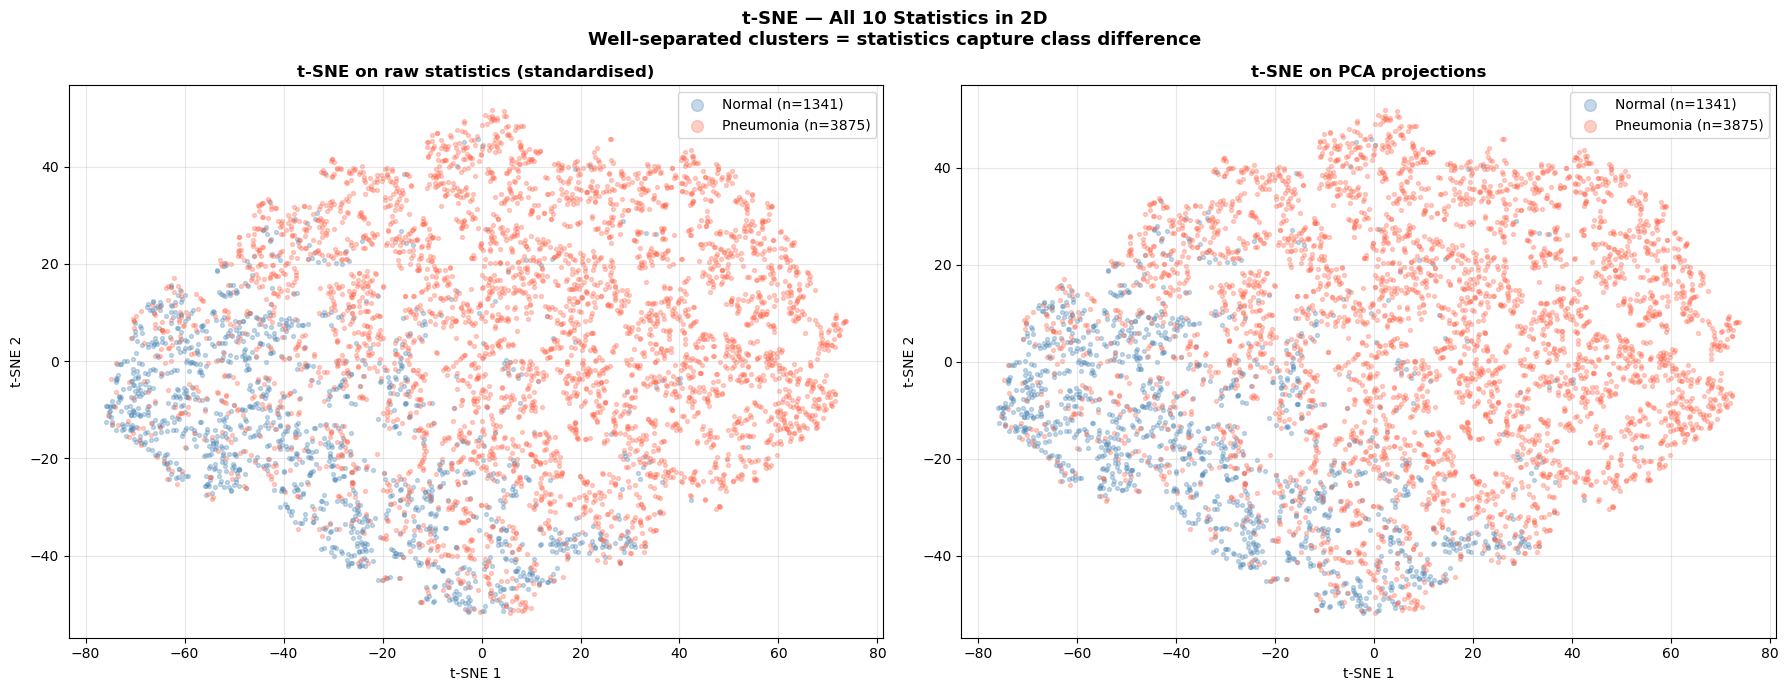

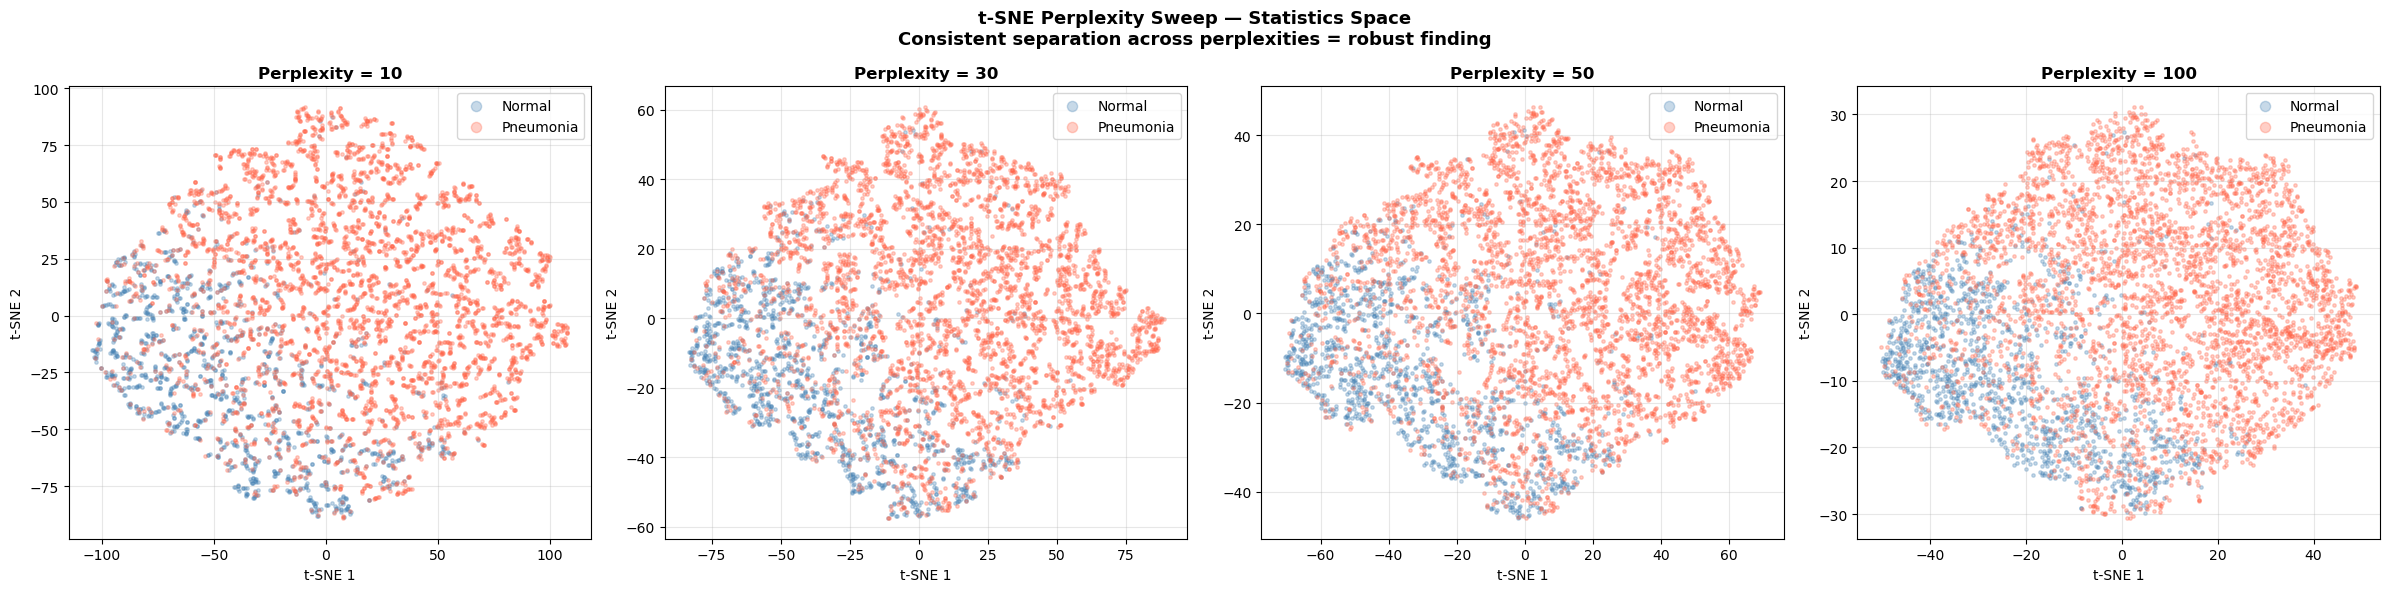

In [46]:
# ── Run t-SNE on the standardised statistics ──────────────────────────────────
# Can run on either the raw standardised features or the PCA projections
# Running on PCA projections first is recommended — denoises the data

print('Running t-SNE...')

tsne = TSNE(
    n_components=2,
    perplexity=40,       # controls local vs global structure
                         # try 20, 40, 80 — larger = more global structure
    learning_rate='auto',
    max_iter=1000,
    random_state=42,
    verbose=1
)

# Option A — t-SNE on standardised statistics directly
X_tsne_stats = tsne.fit_transform(X_scaled)   # (N, 2)

# Option B — t-SNE on PCA projections (faster, denoised)
tsne2        = TSNE(n_components=2, perplexity=40,
                    learning_rate='auto', max_iter=1000,
                    random_state=42, verbose=1)
X_tsne_pca   = tsne2.fit_transform(X_pca)     # (N, 2)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, X_tsne, title in [
    (axes[0], X_tsne_stats, 't-SNE on raw statistics (standardised)'),
    (axes[1], X_tsne_pca,   't-SNE on PCA projections'),
]:
    ax.scatter(X_tsne[y_ints==0, 0], X_tsne[y_ints==0, 1],
               alpha=0.3, s=8, color='steelblue', label=f'Normal (n={int((y_ints==0).sum())})')
    ax.scatter(X_tsne[y_ints==1, 0], X_tsne[y_ints==1, 1],
               alpha=0.3, s=8, color='tomato',    label=f'Pneumonia (n={int((y_ints==1).sum())})')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(markerscale=3)
    ax.grid(alpha=0.3)

plt.suptitle('t-SNE — All 10 Statistics in 2D\n'
             'Well-separated clusters = statistics capture class difference',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Sweep perplexity — t-SNE is sensitive to this parameter ──────────────────
perplexities = [10, 30, 50, 100]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, perp in zip(axes, perplexities):
    tsne_p = TSNE(n_components=2, perplexity=perp,
                  learning_rate='auto', max_iter=1000,
                  random_state=42)
    X_p    = tsne_p.fit_transform(X_scaled)

    ax.scatter(X_p[y_ints==0, 0], X_p[y_ints==0, 1],
               alpha=0.3, s=6, color='steelblue', label='Normal')
    ax.scatter(X_p[y_ints==1, 0], X_p[y_ints==1, 1],
               alpha=0.3, s=6, color='tomato',    label='Pneumonia')
    ax.set_title(f'Perplexity = {perp}', fontweight='bold')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(markerscale=3)
    ax.grid(alpha=0.3)

plt.suptitle('t-SNE Perplexity Sweep — Statistics Space\n'
             'Consistent separation across perplexities = robust finding',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_perplexity_sweep.png', dpi=300, bbox_inches='tight')
plt.show()

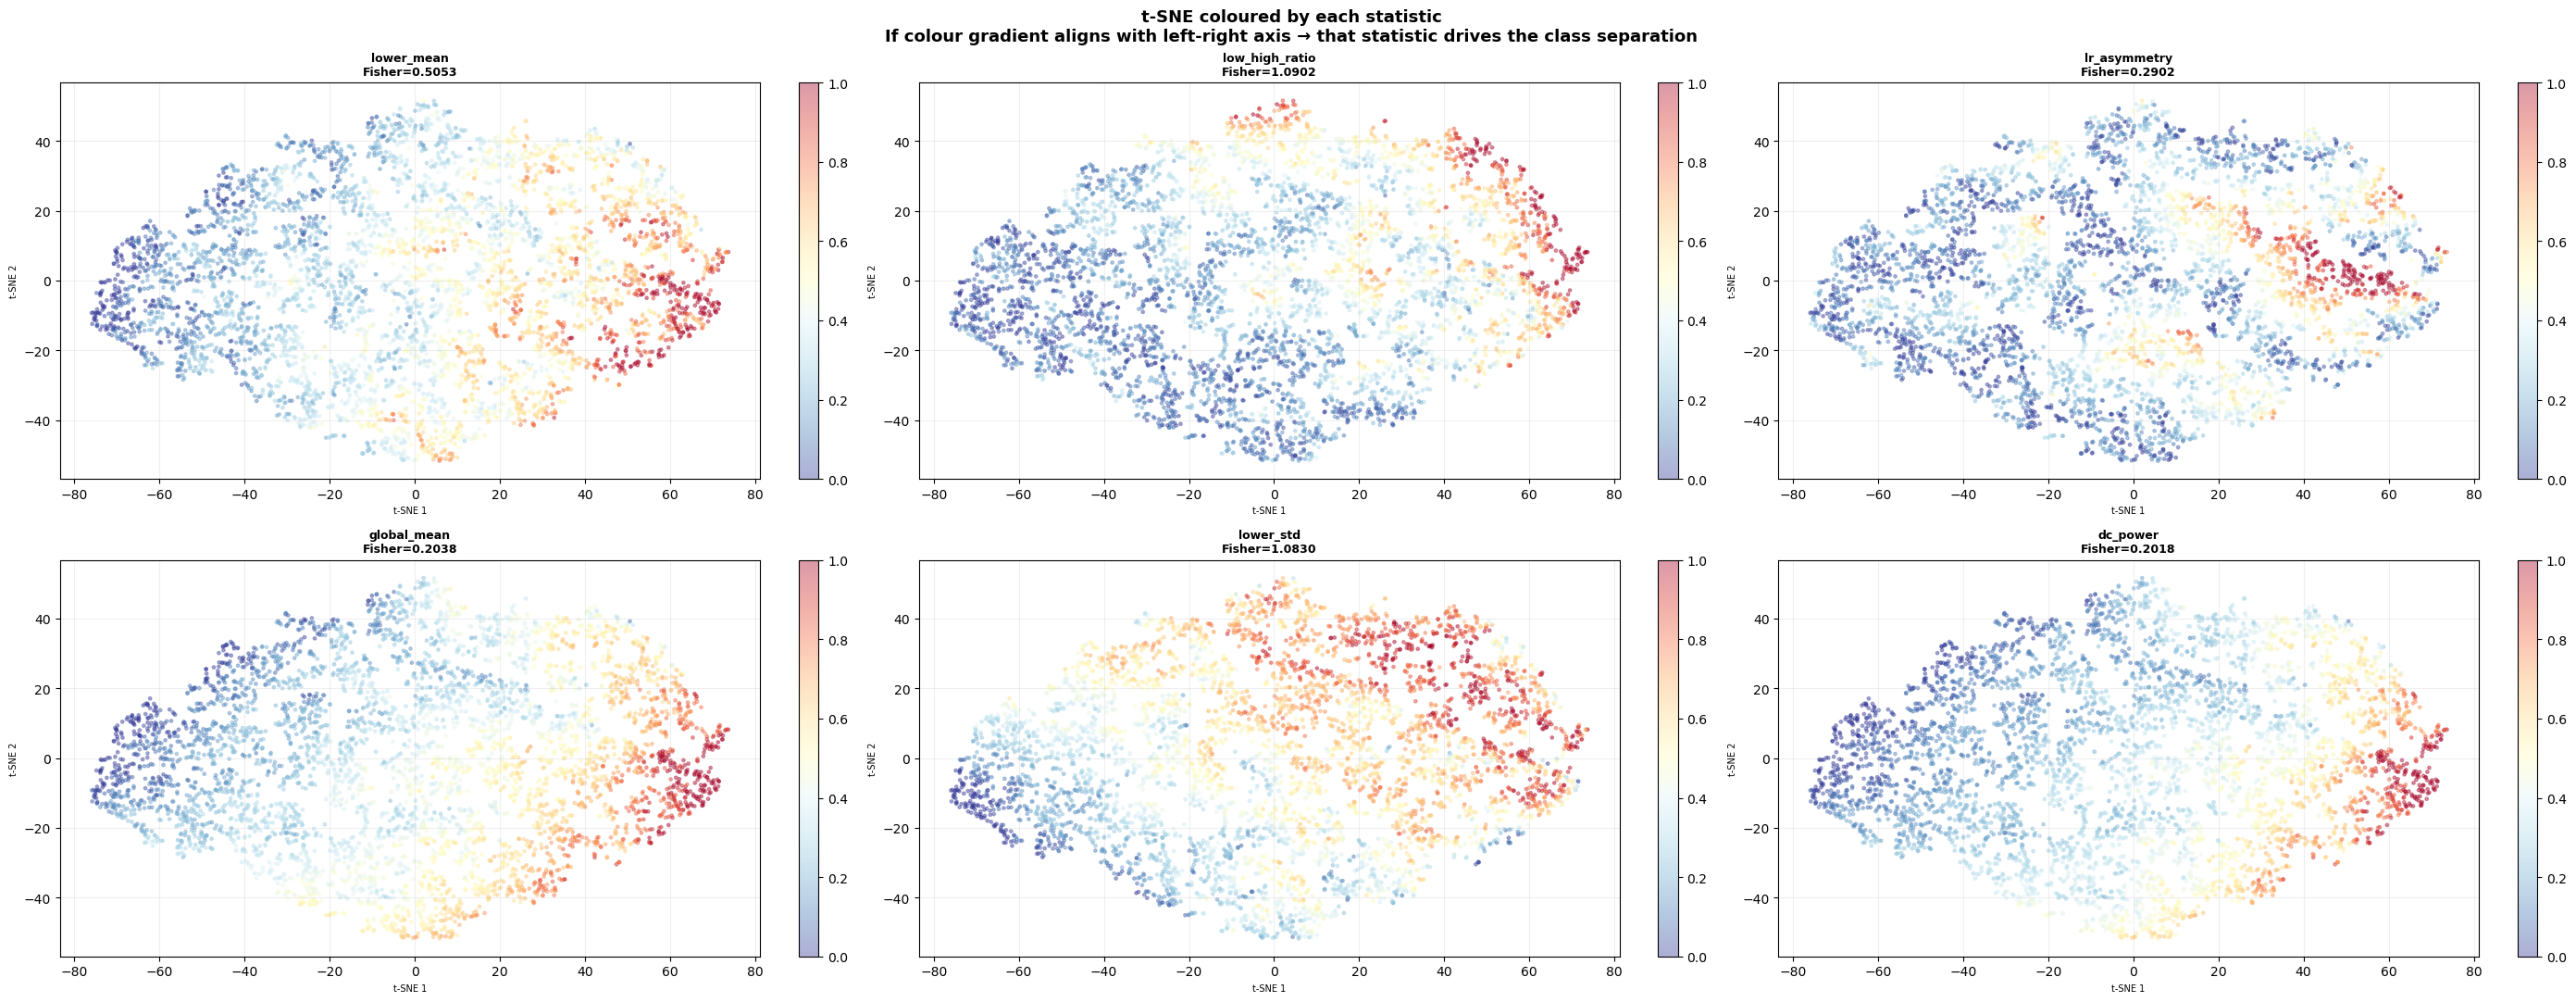

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Use the t-SNE on raw statistics (left plot)
# Colour each point by each of the 10 statistics
# This reveals which statistic drives the left-right separation

fig, axes = plt.subplots(2, 3, figsize=(28, 11))

for idx, (ax, name) in enumerate(zip(axes.flatten(), feature_names)):
    values = X_stats[:, idx]

    # Normalise values to [0,1] for colormap
    v_min  = np.percentile(values, 2)    # robust min
    v_max  = np.percentile(values, 98)   # robust max
    values_norm = np.clip((values - v_min) / (v_max - v_min + 1e-8), 0, 1)

    sc = ax.scatter(X_tsne_stats[:, 0], X_tsne_stats[:, 1],
                    c=values_norm, cmap='RdYlBu_r',
                    alpha=0.4, s=6)
    plt.colorbar(sc, ax=ax, fraction=0.046)

    # Fisher ratio for this feature
    fisher_val = (X_stats[y_ints==1, idx].mean() -
                  X_stats[y_ints==0, idx].mean())**2 / \
                 (X_stats[y_ints==1, idx].std()**2 +
                  X_stats[y_ints==0, idx].std()**2 + 1e-8)

    ax.set_title(f'{name}\nFisher={fisher_val:.4f}',
                  fontweight='bold', fontsize=9)
    ax.set_xlabel('t-SNE 1', fontsize=7)
    ax.set_ylabel('t-SNE 2', fontsize=7)
    ax.grid(alpha=0.2)

plt.suptitle('t-SNE coloured by each statistic\n'
             'If colour gradient aligns with left-right axis → '
             'that statistic drives the class separation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_coloured_by_statistic.png', dpi=300, bbox_inches='tight')
plt.show()